In [861]:
import numpy as np
import pandas as pd
import math as math
from scipy import optimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

from MoorLib import moorSeg
from MoorLib import moorLine2D
from MoorLib import moorLine3D

import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

(-100.0, 0.0)

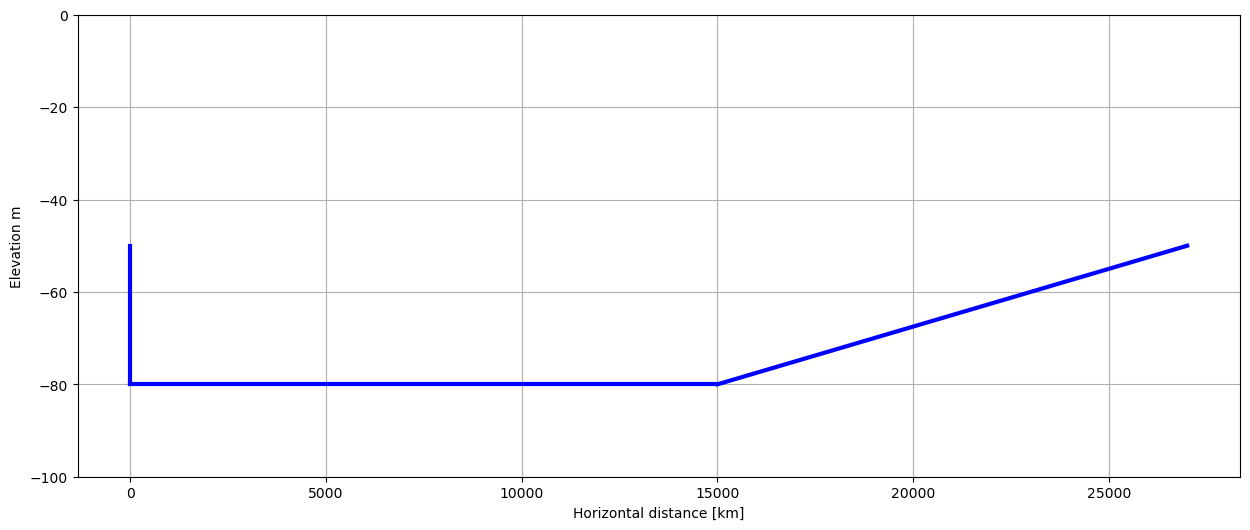

In [862]:
x1 = np.linspace(0, 15000)
x2 = np.linspace(15000, 27000)

y1 = -80 + 0*x1
y2 = -80 - 1/400 * (15000 - x2) 

plt.figure()
plt.plot(x1, y1, 'b-', lw=3)
plt.plot(x2, y2, 'b-', lw=3)
plt.axvline(x = 0, ymin = 0.2, ymax = 0.5, color = 'b', lw=3)
plt.grid()
plt.xlabel('Horizontal distance [km]')
plt.ylabel('Elevation m')
plt.ylim(-100, 0)

In [863]:
B          = 28.0          # Structure width [m]
x_att      = B / 2        # Half-width: horizontal distance attachment → centreline [m]
z_att      = -27.5          # Vertical distance: attachment point → seabed [m]

q_low = 276.36
q_high = 358.86

spacing = 25
length = np.arange(0, 27025, spacing)

L0_factor  = 0.98

# E = 3423599664
E = 5 * 10**9
diam = 0.3
EA = E * (np.pi / 4 * diam**2)
print(EA / 10**6)

353.4291735288517


In [864]:
# for i in range(len(length)):
#     y = length[i]
#     if y < 15000:
#         d = 80
#     else:
#         d = 80 + 1/400 * (15000 - y)

#     x_anch = x_att * 1.2 * 1.03**((d - 50) / 30)
    
#     z = -(d + z_att)

#     L0         = L0_factor * -z
#     strain0    = (-z - L0) / L0
#     T0         = EA * strain0

#     if y in [10000, 19000, 23000, 26950]:
#         # Left side
#         x_left = [-x_anch, -x_att]
#         y_left = [z, 0]

#         x_right = [x_anch, x_att]
#         y_right = [z, 0]

#         # Plot
#         plt.figure(figsize=(6, 6))
#         plt.plot(x_left, y_left, 'b-', linewidth=2, label='Mooring line')
#         plt.plot(x_right, y_right, 'b-', linewidth=2)
#         plt.scatter([-x_anch, x_anch], [z, z], color='black', label='Anchors')
#         plt.scatter([-x_att, x_att], [0, 0], color='red', label='Attachments')
#         plt.xlabel('Horizontal position [m]')
#         plt.ylabel('Vertical position [m]')
#         plt.title('2D Mooring Line Geometry')
#         plt.legend()
#         plt.grid()
#         plt.axis('equal')

#         plt.show()


In [865]:
def cable_length(dx_struct, dz_struct, side='port'):
    """
    Geometric length of one cable given the structural displacement.
    side = 'port'  → left  cable  (attachment at -x_att, anchor at -x_anc)
    side = 'starboard' → right cable (attachment at +x_att, anchor at +x_anc)
    dx_struct: positive = rightward displacement of structure centre
    dz_struct: positive = upward displacement of structure
    """
    sign = -1 if side == 'port' else +1
    # Vector from anchor to attachment point in displaced state
    dx_cable = sign * x_att + dx_struct - sign * x_anch   # horizontal component
    dz_cable = -z + dz_struct                              # vertical component
    return np.sqrt(dx_cable**2 + dz_cable**2)


def cable_tension(dx_struct, dz_struct, side='port'):
    """Tension in the cable [N]. Zero if cable would go slack."""
    L = cable_length(dx_struct, dz_struct, side)
    strain = (L - L0) / L0
    return max(0.0, EA * strain)


def cable_direction(dx_struct, dz_struct, side='port'):
    """
    Unit vector FROM anchor TO attachment point.
    Returns (cos_theta_h, cos_theta_v) = (horizontal, vertical) direction cosines.
    """
    sign = -1 if side == 'port' else +1
    dx_cable = sign * x_att + dx_struct - sign * x_anch
    dz_cable = -z + dz_struct
    L = np.sqrt(dx_cable**2 + dz_cable**2)
    return dx_cable / L, dz_cable / L


def total_restoring_force(dx_struct, dz_struct):
    """
    Net restoring force on the structure [N] for a given displacement.
    Returns (Fx, Fz) where positive Fx is rightward, positive Fz is upward.
    The restoring force opposes the displacement, so sign is defined as
    the net cable force acting on the structure (anchor pulls attachment inward/downward).
    """
    Fx = 0.0
    Fz = 0.0
    for side in ('port', 'starboard'):
        T  = cable_tension(dx_struct, dz_struct, side)
        ch, cv = cable_direction(dx_struct, dz_struct, side)
        # Force ON structure from cable acts from attachment toward anchor → reverse direction
        Fx += -T * ch
        Fz += -T * cv
    return Fx, Fz

# Quick sanity check at neutral position
Fx0, Fz0 = total_restoring_force(0, 0)
print(f'Neutral position net force: Fx = {Fx0/1e3:.3f} kN,  Fz = {Fz0/1e3:.3f} kN')
print(f'(Both should be ~0 N for symmetric vertical geometry)')
print(f'Pre-tension each cable: {cable_tension(0, 0, "port")/1e3:.2f} kN')

Neutral position net force: Fx = nan kN,  Fz = nan kN
(Both should be ~0 N for symmetric vertical geometry)
Pre-tension each cable: 0.00 kN


In [866]:
# ── Cell 5: Per-attachment geometry and equilibrium pre-tension ──────────
#
# For each attachment row, solve L0 such that the two taut lines together
# provide exactly q_low * spacing [kN] of upward force — vertical equilibrium
# under the reduced buoyancy condition.  When buoyancy increases to q_high
# the structure can only move upward from this reference state.

attachments = []   # list of dicts, one per row

for y in length:
    if y < 15000:
        d = 80.0
    else:
        d = 80.0 + (15000 - y) / 400.0   # shallows beyond 15 km

    x_anch = x_att * (1.4 + 1.2 * ((d - 50) / 30)**1.2)                      #* (1.4 + 0.04 * (d - 50))  
    z_anc  = -d                          # anchor at seabed [m from surface]
    z_fl   = z_att                       # attachment elevation [m from surface]

    # Cable vector (port side) from anchor to attachment at neutral position
    # port: anchor at (-x_anch, z_anc), attachment at (-x_att, z_fl)
    dx_p   = (-x_att) - (-x_anch)          # = x_anch - x_att > 0
    dz_p   = z_fl - z_anc                  # positive upward (attachment above anchor)
    L_geom = np.sqrt(dx_p**2 + dz_p**2)
    cv     = dz_p / L_geom                 # vertical direction cosine

    # Solve for L0: 2 * EA*(L_geom/L0 - 1) * cv = q_low * spacing * 1e3
    F_req  = q_low * spacing * 1e3         # N upward per attachment row
    T_req  = F_req / (2.0 * cv)            # required tension per cable
    L0     = L_geom / (1.0 + T_req / EA)   # natural length

    T0     = EA * (L_geom - L0) / L0       # pre-tension [N]

    attachments.append({
        'y':       y,
        'd':       d,
        'x_anch':  x_anch,
        'z_anc':   z_anc,
        'z_fl':    z_fl,
        'L_geom':  L_geom,
        'L0':      L0,
        'T0_kN':   T0 / 1e3,
        'cv':      cv,
        'ch':      dx_p / L_geom,
    })

df_att = pd.DataFrame(attachments)
print(f"Total attachment rows : {len(df_att)}")
print(f"Depth range           : {df_att['d'].min():.1f} – {df_att['d'].max():.1f} m")
print(f"Pre-tension range     : {df_att['T0_kN'].min():.1f} – {df_att['T0_kN'].max():.1f} kN")
print(f"\nFirst 3 rows:")
print(df_att[['y','d','x_anch','z_fl','L0','T0_kN']].head(3).to_string(index=False, float_format='{:.3f}'.format))
print(f"\nLast 3 rows:")
print(df_att[['y','d','x_anch','z_fl','L0','T0_kN']].tail(3).to_string(index=False, float_format='{:.3f}'.format))


Total attachment rows : 1081
Depth range           : 50.0 – 80.0 m
Pre-tension range     : 3559.6 – 3755.8 kN

First 3 rows:
 y      d  x_anch    z_fl     L0    T0_kN
 0 80.000  36.400 -27.500 56.479 3755.797
25 80.000  36.400 -27.500 56.479 3755.797
50 80.000  36.400 -27.500 56.479 3755.797

Last 3 rows:
    y      d  x_anch    z_fl     L0    T0_kN
26950 50.125  19.623 -27.500 23.081 3559.604
26975 50.062  19.610 -27.500 23.018 3559.689
27000 50.000  19.600 -27.500 22.955 3559.888


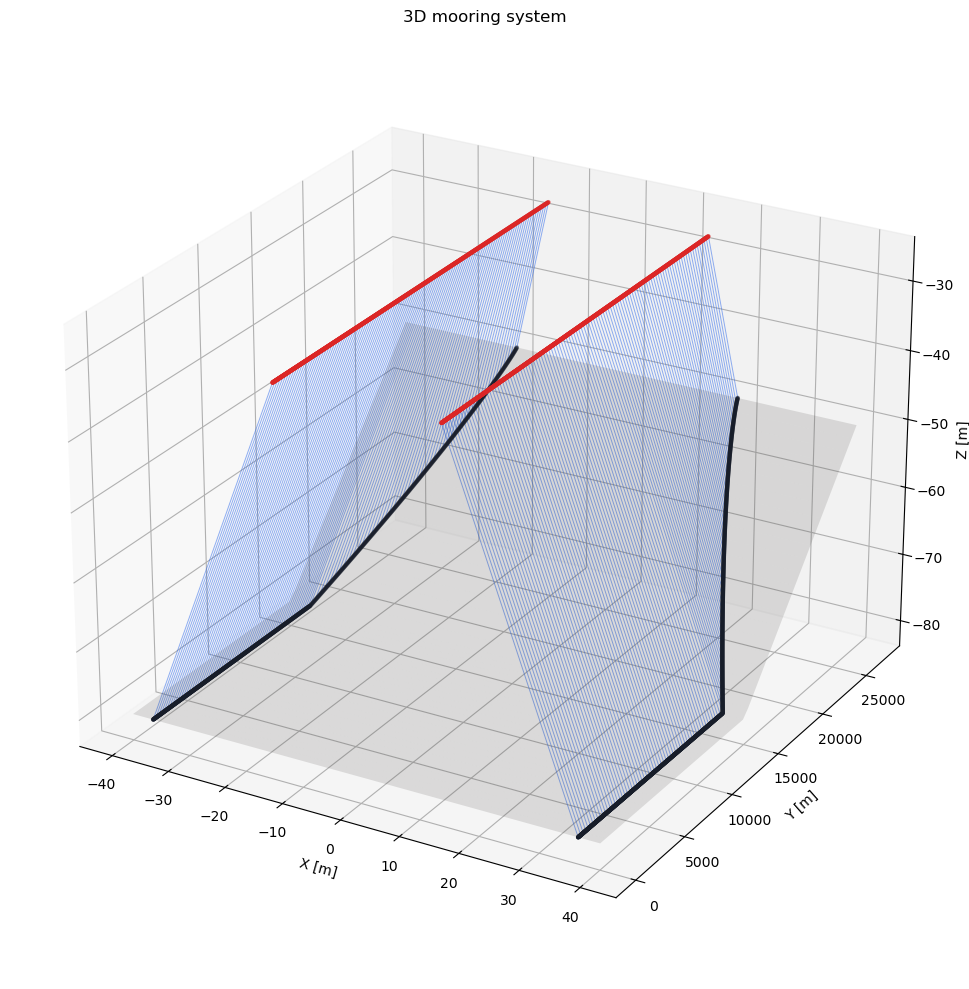

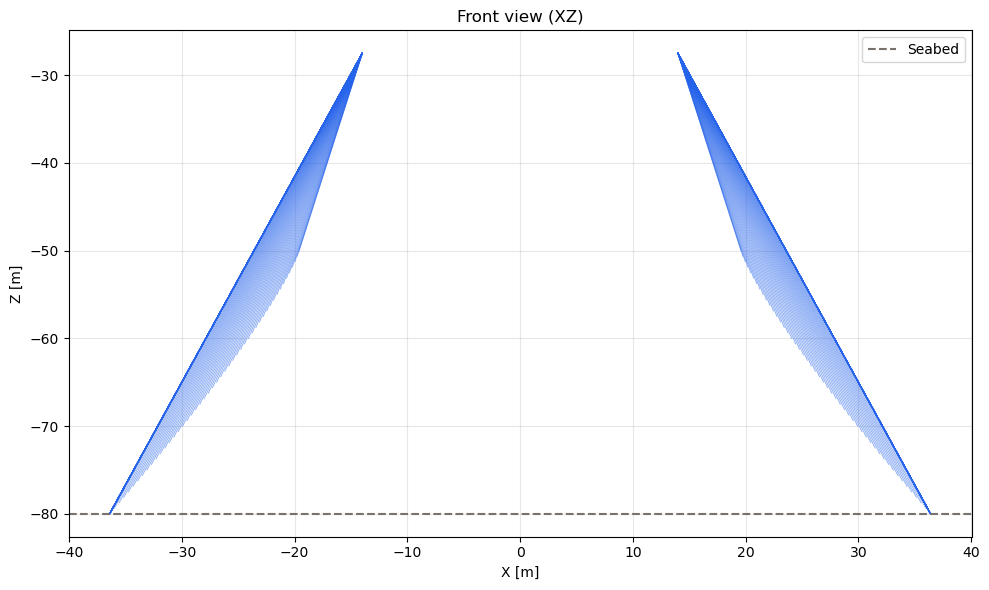

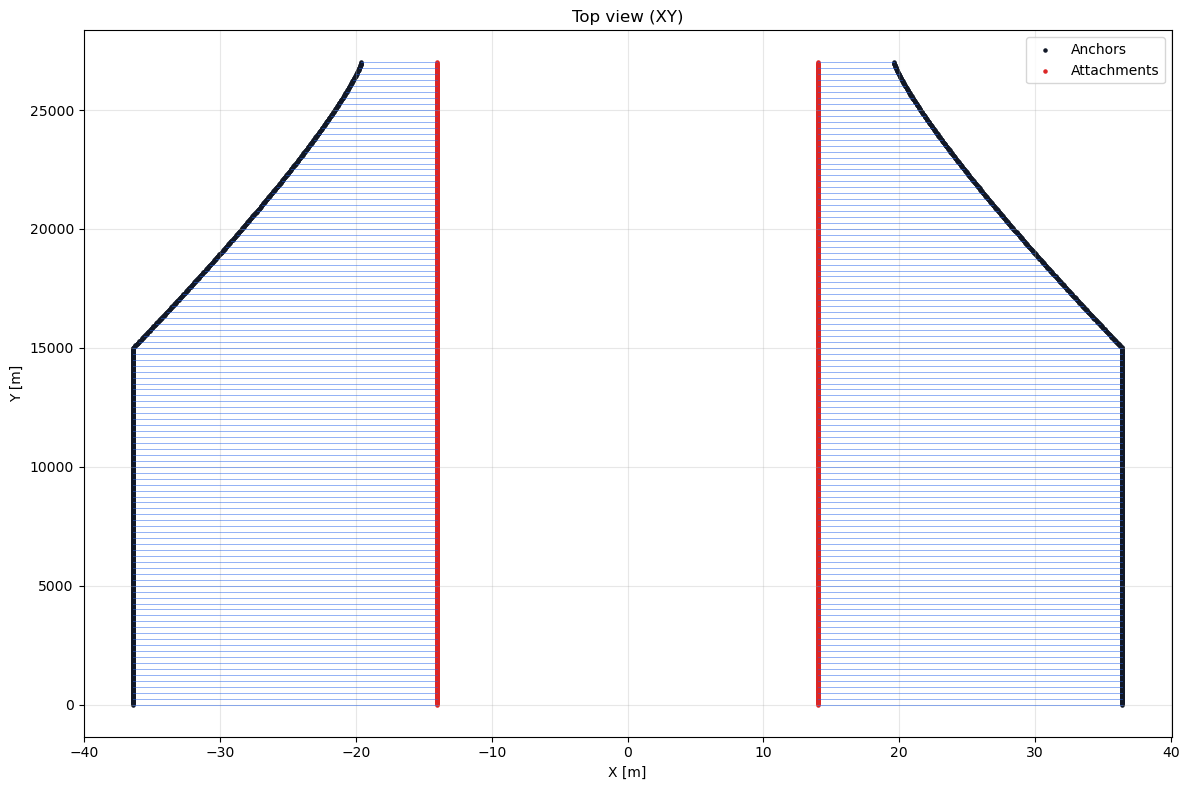

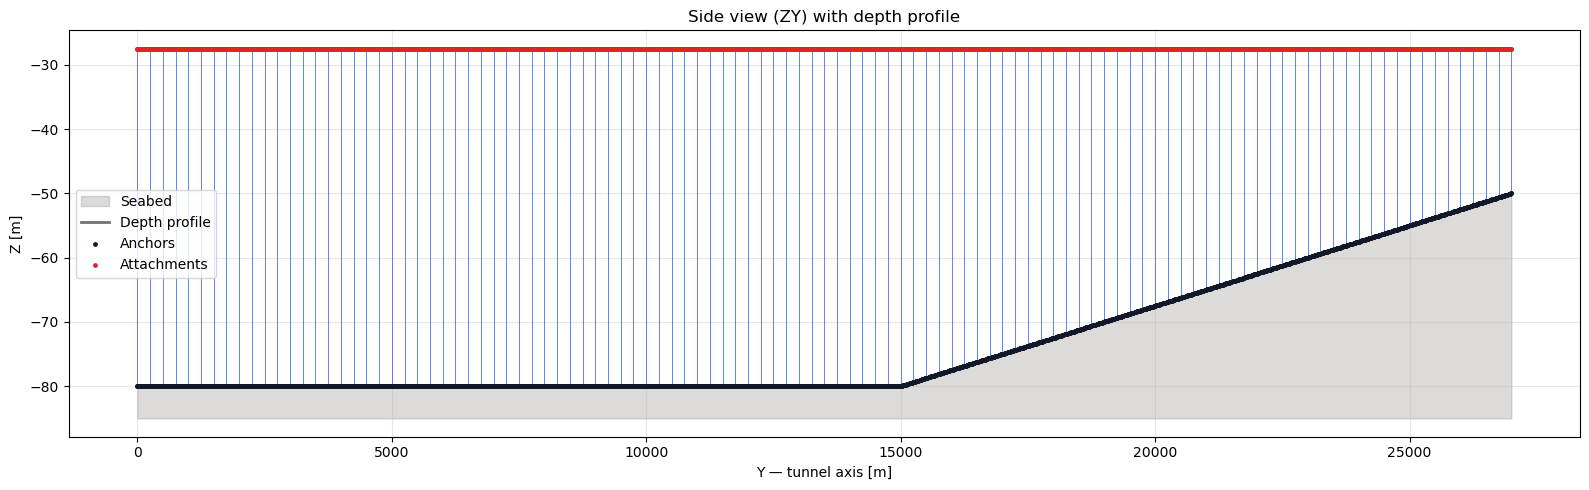

In [867]:
# ── Cell 6: Separate figures for each view ───────────────────────────────

# ── Depth profile ────────────────────────────────────────────────────────
y_prof = np.linspace(0, 27000, 500)
d_prof = np.where(y_prof < 15000, 80.0, 80.0 + (15000 - y_prof) / 400.0)
z_seabed = -d_prof

# ── Build line segment lists ──────────────────────────────────────────────
segs_port   = []
segs_star   = []
anchors_xyz = []
attach_xyz  = []

for a in attachments:
    y, x_anch, z_anc, z_fl = a['y'], a['x_anch'], a['z_anc'], a['z_fl']
    segs_port.append([(-x_anch, y, z_anc), (-x_att, y, z_fl)])
    segs_star.append([( x_anch, y, z_anc), ( x_att, y, z_fl)])
    anchors_xyz.extend([(-x_anch, y, z_anc), ( x_anch, y, z_anc)])
    attach_xyz.extend( [(-x_att,  y, z_fl),  ( x_att,  y, z_fl)])

anchors_xyz = np.array(anchors_xyz)
attach_xyz  = np.array(attach_xyz)

# ── Plot every 10th line ─────────────────────────────────────────────────
plot_idx = np.arange(0, len(segs_port), 10)
segs_port_plot = [segs_port[i] for i in plot_idx]
segs_star_plot = [segs_star[i] for i in plot_idx]

# ── Colors ───────────────────────────────────────────────────────────────
C_LINE = '#2563EB'; C_ANCH = '#111827'; C_ATT = '#DC2626'; C_BED = '#78716C'

# =========================================================================
# FIGURE 1 — 3D VIEW
# =========================================================================
fig = plt.figure(figsize=(14, 10))
ax3d = fig.add_subplot(111, projection='3d')

for (a0, a1), (b0, b1) in zip(segs_port_plot, segs_star_plot):
    ax3d.plot([a0[0], a1[0]], [a0[1], a1[1]], [a0[2], a1[2]], color=C_LINE, lw=0.7, alpha=0.5)
    ax3d.plot([b0[0], b1[0]], [b0[1], b1[1]], [b0[2], b1[2]],  color=C_LINE, lw=0.7, alpha=0.5)

ax3d.scatter(anchors_xyz[:,0], anchors_xyz[:,1], anchors_xyz[:,2], color=C_ANCH, s=5)
ax3d.scatter(attach_xyz[:,0], attach_xyz[:,1], attach_xyz[:,2], color=C_ATT, s=5)

y_bed = np.linspace(0, 27000, 50)
x_bed = np.array([-40, 40])
Y_bed, X_bed = np.meshgrid(y_bed, x_bed)
D_bed = np.where(Y_bed < 15000, 80.0, 80.0 + (15000 - Y_bed) / 400.0)

ax3d.plot_surface(X_bed, Y_bed, -D_bed, alpha=0.15, color=C_BED)

ax3d.set_xlabel('X [m]')
ax3d.set_ylabel('Y [m]')
ax3d.set_zlabel('Z [m]')
ax3d.set_title('3D mooring system')
ax3d.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()

# =========================================================================
# FIGURE 2 — FRONT VIEW (XZ)
# =========================================================================
fig, ax_xz = plt.subplots(figsize=(10, 6))

for a0, a1 in segs_port_plot:
    ax_xz.plot([a0[0], a1[0]], [a0[2], a1[2]], color=C_LINE, lw=0.7, alpha=0.5)

for b0, b1 in segs_star_plot:
    ax_xz.plot([b0[0], b1[0]], [b0[2], b1[2]], color=C_LINE, lw=0.7, alpha=0.5)

ax_xz.axhline(-80, color=C_BED, lw=1.5, ls='--', label='Seabed')

ax_xz.set_xlabel('X [m]')
ax_xz.set_ylabel('Z [m]')
ax_xz.set_title('Front view (XZ)')
ax_xz.grid(True, alpha=0.3)
ax_xz.legend()

plt.tight_layout()
plt.show()

# =========================================================================
# FIGURE 3 — TOP VIEW (XY)
# =========================================================================
fig, ax_xy = plt.subplots(figsize=(12, 8))

ax_xy.scatter(anchors_xyz[:,0], anchors_xyz[:,1], color=C_ANCH, s=5, label='Anchors')
ax_xy.scatter(attach_xyz[:,0], attach_xyz[:,1], color=C_ATT, s=5, label='Attachments')

for a0, a1 in segs_port_plot:
    ax_xy.plot([a0[0], a1[0]], [a0[1], a1[1]], color=C_LINE, lw=0.7, alpha=0.5)

for b0, b1 in segs_star_plot:
    ax_xy.plot([b0[0], b1[0]], [b0[1], b1[1]], color=C_LINE, lw=0.7, alpha=0.5)

ax_xy.set_xlabel('X [m]')
ax_xy.set_ylabel('Y [m]')
ax_xy.set_title('Top view (XY)')
ax_xy.grid(True, alpha=0.3)
ax_xy.legend()

plt.tight_layout()
plt.show()

# =========================================================================
# FIGURE 4 — SIDE VIEW (ZY)
# =========================================================================
fig, ax_zy = plt.subplots(figsize=(16, 5))

ax_zy.fill_between(y_prof, z_seabed, z_seabed.min() - 5,color=C_BED, alpha=0.25, label='Seabed')
ax_zy.plot(y_prof, z_seabed, color=C_BED, lw=2, label='Depth profile')

for a0, a1 in segs_port_plot:
    ax_zy.plot([a0[1], a1[1]], [a0[2], a1[2]], color=C_LINE, lw=0.7, alpha=0.5)

for b0, b1 in segs_star_plot:
    ax_zy.plot([b0[1], b1[1]], [b0[2], b1[2]], color=C_LINE, lw=0.7, alpha=0.5)

ax_zy.scatter(anchors_xyz[:,1], anchors_xyz[:,2], color=C_ANCH, s=6, zorder=5, label='Anchors')
ax_zy.scatter(attach_xyz[:,1], attach_xyz[:,2], color=C_ATT, s=6, zorder=5, label='Attachments')

ax_zy.set_xlabel('Y — tunnel axis [m]')
ax_zy.set_ylabel('Z [m]')
ax_zy.set_title('Side view (ZY) with depth profile')

ax_zy.grid(True, alpha=0.3)
ax_zy.legend()

plt.tight_layout()
plt.show()

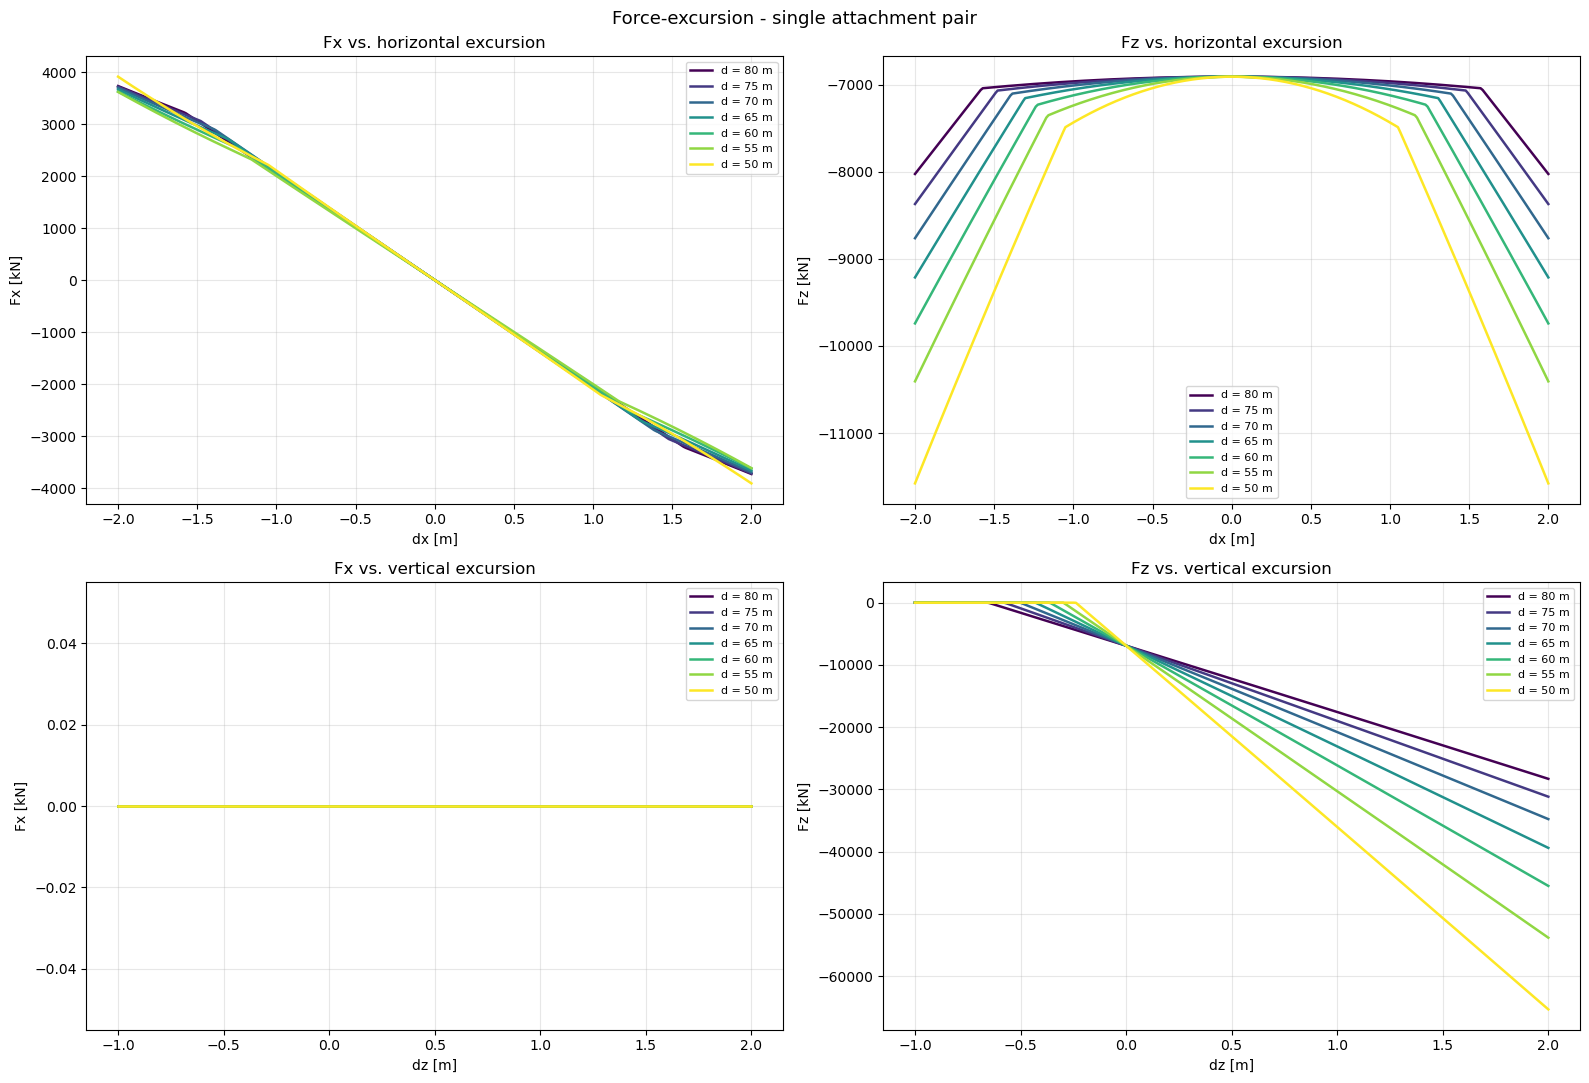

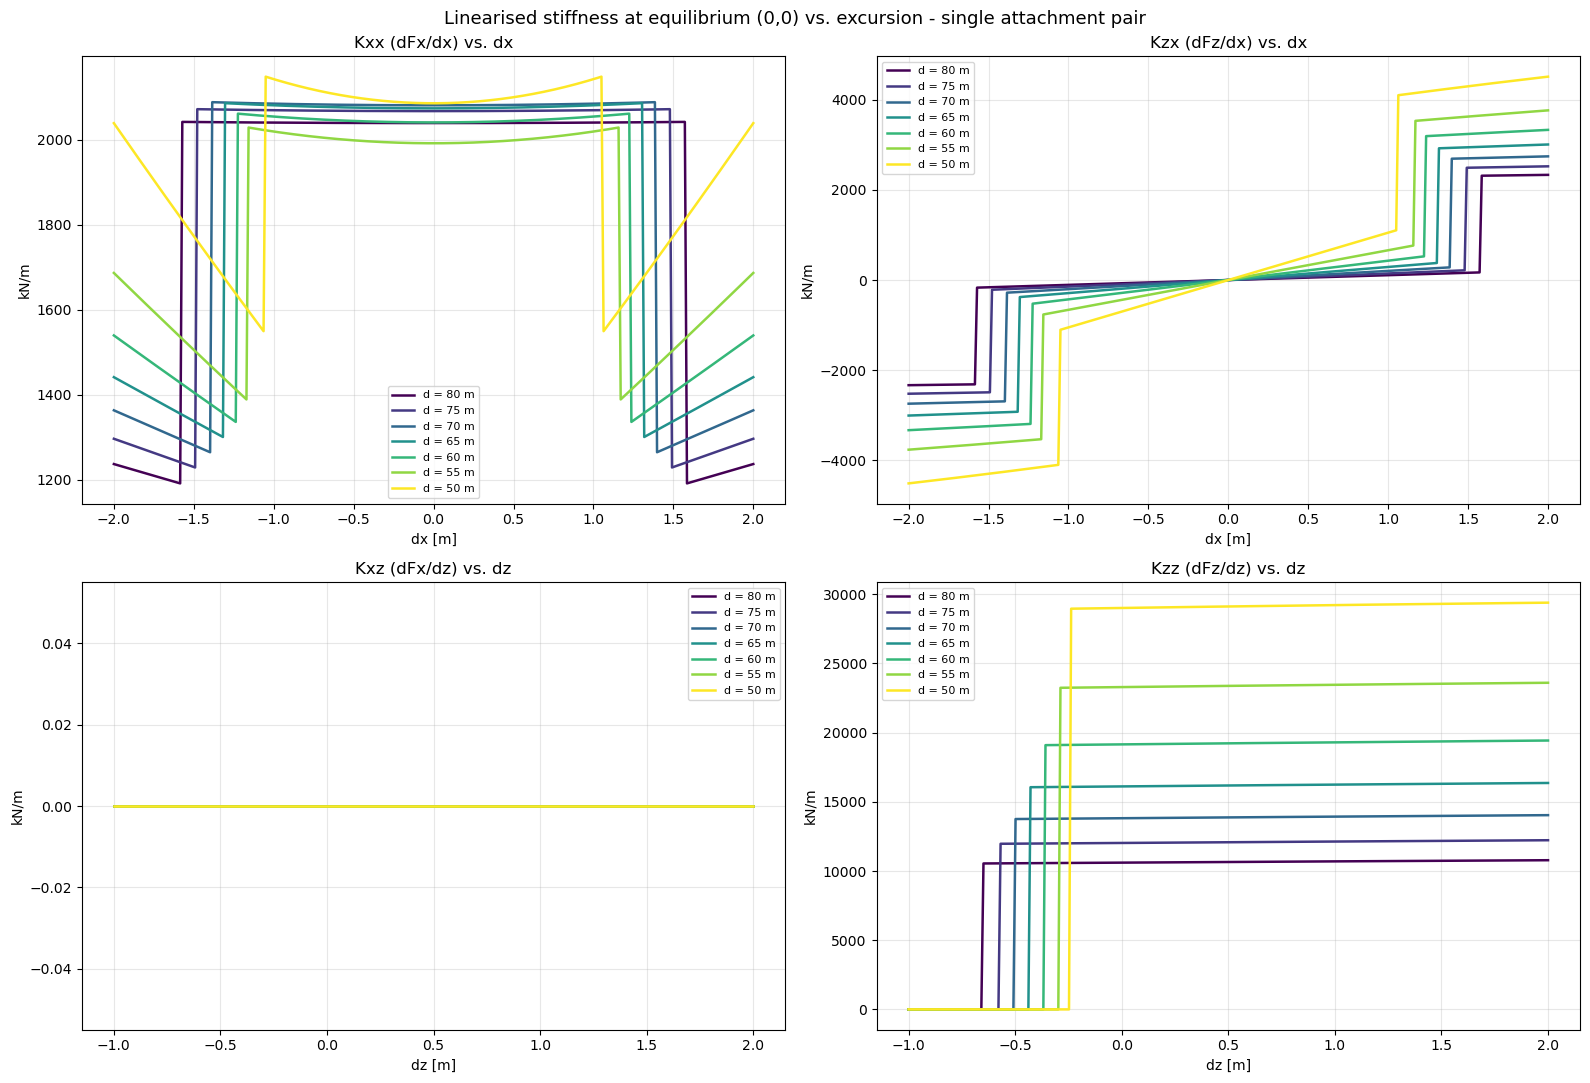

Design-load linearisation
  Applied load per attachment row: Fz = 8971.5 kN (up), Fx = 1958.0 kN (horizontal)
   Depth    dx* [m]    dz* [m]        Kxx        Kxz        Kzx        Kzz  (kN/m)
  d= 80 m  dx*=+0.9507  dz*=+0.1897  Kxx=  2060.19  Kxz=   102.05  Kzx=   102.05  Kzz= 10625.54
  d= 75 m  dx*=+0.9361  dz*=+0.1660  Kxx=  2092.94  Kxz=   136.28  Kzx=   136.28  Kzz= 12047.69
  d= 70 m  dx*=+0.9277  dz*=+0.1429  Kxx=  2112.79  Kxz=   187.58  Kzx=   187.58  Kzz= 13834.34
  d= 65 m  dx*=+0.9279  dz*=+0.1202  Kxx=  2114.34  Kxz=   268.11  Kzx=   268.11  Kzz= 16130.93
  d= 60 m  dx*=+0.9385  dz*=+0.0978  Kxx=  2094.29  Kxz=   401.17  Kzx=   401.17  Kzz= 19164.01
  d= 55 m  dx*=+0.9553  dz*=+0.0756  Kxx=  2066.33  Kxz=   629.20  Kzx=   629.20  Kzz= 23295.46
  d= 50 m  dx*=+0.9065  dz*=+0.0562  Kxx=  2190.83  Kxz=   949.61  Kzx=   949.61  Kzz= 28999.86


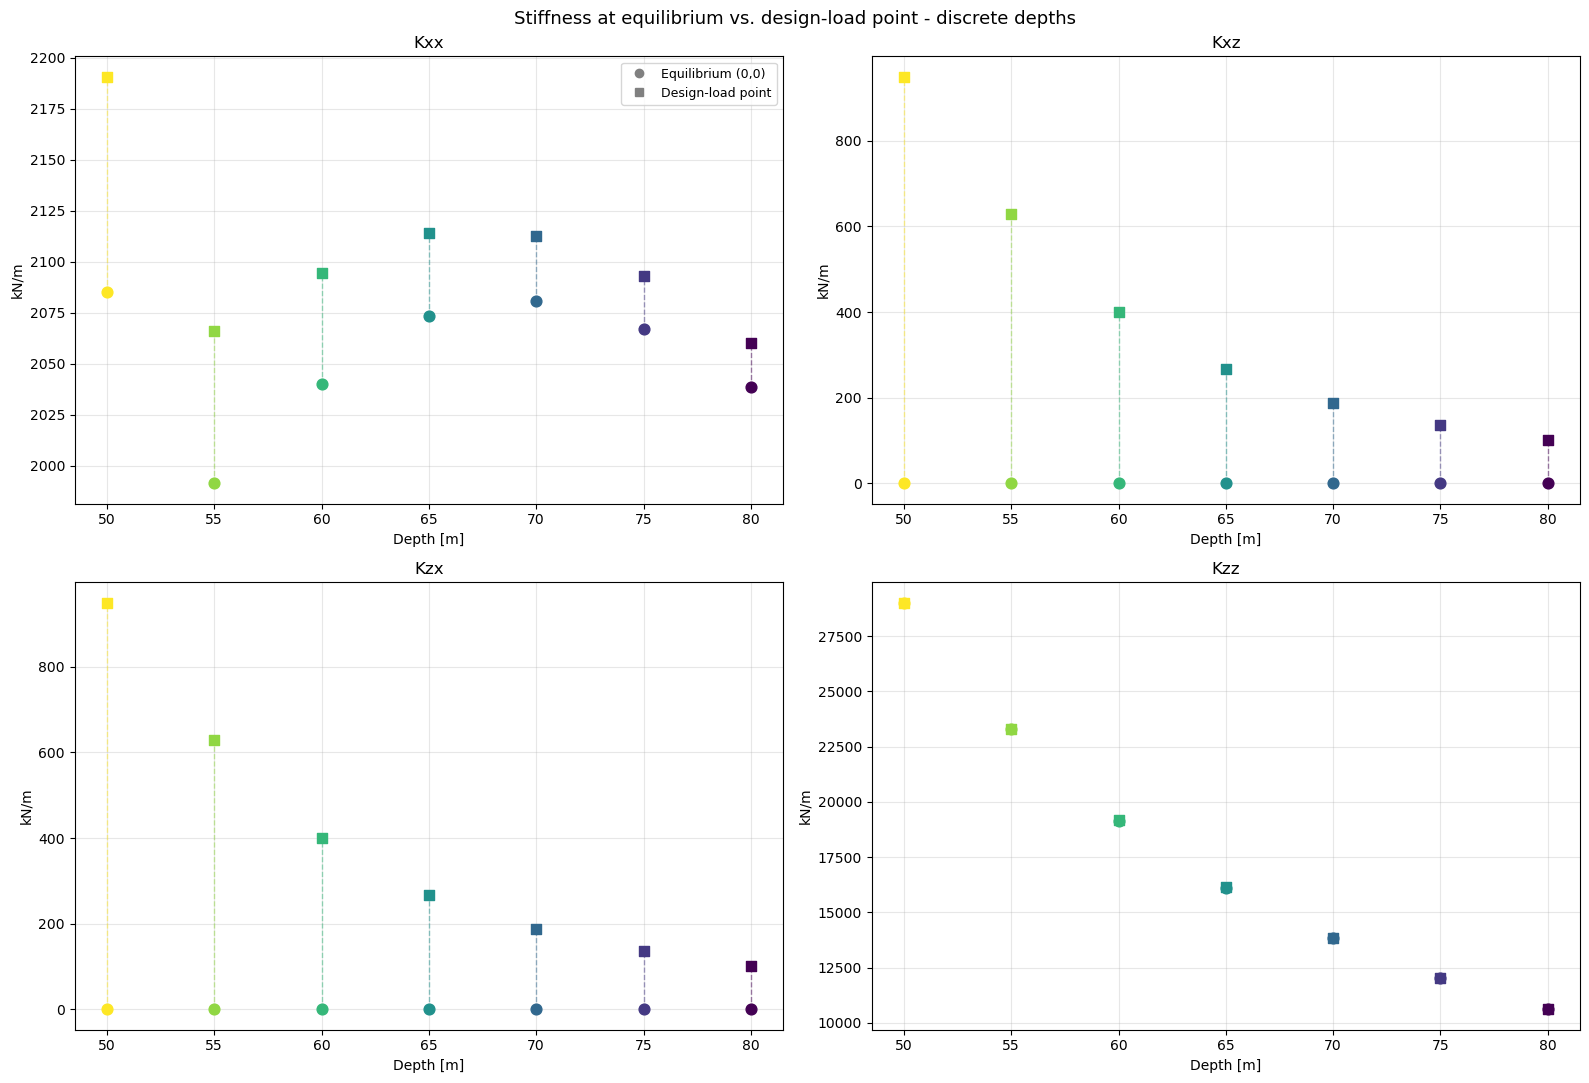

In [868]:
# ── Cell 7: Force-excursion and stiffness diagrams at discrete depths ────
# Single attachment pair (port + starboard) response across a range of
# horizontal (dx) and vertical (dz) displacements, evaluated at 7 depths.
#
# Stiffness is shown linearised at TWO reference points per depth:
#   (1) Equilibrium (dx=0, dz=0)  - symmetric, so Kxz = 0
#   (2) Design-load point          - solved from Fz = q_high*spacing, Fx = F_horiz*spacing



depths_plot = [80, 75, 70, 65, 60, 55, 50]
dx_range    = np.linspace(-2.0,  2.0, 300)   # m
dz_range    = np.linspace(-1.0,  2.0, 300)   # m (positive = upward)

# Design loads per attachment row [kN]
q_high     = 358.86   # kN/m  buoyancy at design condition
F_horiz    = 78.32    # kN/m  horizontal load (current etc.)
Fz_des_row = q_high  * spacing   # kN per attachment row
Fx_des_row = F_horiz * spacing   # kN per attachment row

def attachment_forces(a, dx, dz):
    Fx = 0.0; Fz = 0.0
    for sign in (-1, +1):
        x_fl_d = sign * x_att + dx
        z_fl_d = a['z_fl'] + dz
        ddx    = x_fl_d - sign * a['x_anch']
        ddz    = z_fl_d - a['z_anc']
        L      = np.sqrt(ddx**2 + ddz**2)
        strain = (L - a['L0']) / a['L0']
        T      = max(0.0, EA * strain)
        Fx    += -T * ddx / L
        Fz    += -T * ddz / L
    return Fx, Fz

def stiffness_at_point(a, dx0, dz0, eps=1e-4):
    Kxx = -(attachment_forces(a, dx0+eps, dz0  )[0] - attachment_forces(a, dx0-eps, dz0  )[0]) / (2*eps*1e3)
    Kzx = -(attachment_forces(a, dx0+eps, dz0  )[1] - attachment_forces(a, dx0-eps, dz0  )[1]) / (2*eps*1e3)
    Kxz = -(attachment_forces(a, dx0,     dz0+eps)[0] - attachment_forces(a, dx0,     dz0-eps)[0]) / (2*eps*1e3)
    Kzz = -(attachment_forces(a, dx0,     dz0+eps)[1] - attachment_forces(a, dx0,     dz0-eps)[1]) / (2*eps*1e3)
    return np.array([[Kxx, Kxz], [Kzx, Kzz]])

def find_design_point(a, Fx_kN, Fz_kN, x0=(0.05, 0.2)):
    # Find (dx*, dz*) such that cable forces balance the design loads.
    # Cables produce a restoring force equal and opposite to the applied loads.
    def residuals(p):
        dx, dz = p
        Fx, Fz = attachment_forces(a, dx, dz)
        return [Fx/1e3 + Fx_kN, Fz/1e3 + Fz_kN]
    sol, _, ier, msg = fsolve(residuals, x0, full_output=True)
    if ier != 1:
        print(f'  Warning - design-point solver did not converge: {msg}')
    return sol

# Lookup: target depth -> representative attachment
depth_att = {}
for d_t in depths_plot:
    idx = (df_att['d'] - d_t).abs().idxmin()
    depth_att[d_t] = attachments[idx]

colors = plt.cm.viridis(np.linspace(0, 1, len(depths_plot)))
eps = 1e-4

# ── Force-excursion ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
(ax_Fx_dx, ax_Fz_dx), (ax_Fx_dz, ax_Fz_dz) = axes

for col, d_t in zip(colors, depths_plot):
    a   = depth_att[d_t]; lbl = f'd = {d_t} m'
    Fx_dx = [attachment_forces(a, dx, 0)[0]/1e3 for dx in dx_range]
    Fz_dx = [attachment_forces(a, dx, 0)[1]/1e3 for dx in dx_range]
    Fx_dz = [attachment_forces(a, 0,  dz)[0]/1e3 for dz in dz_range]
    Fz_dz = [attachment_forces(a, 0,  dz)[1]/1e3 for dz in dz_range]
    ax_Fx_dx.plot(dx_range, Fx_dx, color=col, lw=1.8, label=lbl)
    ax_Fz_dx.plot(dx_range, Fz_dx, color=col, lw=1.8, label=lbl)
    ax_Fx_dz.plot(dz_range, Fx_dz, color=col, lw=1.8, label=lbl)
    ax_Fz_dz.plot(dz_range, Fz_dz, color=col, lw=1.8, label=lbl)

for ax in axes.flat:
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax_Fx_dx.set(title='Fx vs. horizontal excursion', xlabel='dx [m]', ylabel='Fx [kN]')
ax_Fz_dx.set(title='Fz vs. horizontal excursion', xlabel='dx [m]', ylabel='Fz [kN]')
ax_Fx_dz.set(title='Fx vs. vertical excursion',   xlabel='dz [m]', ylabel='Fx [kN]')
ax_Fz_dz.set(title='Fz vs. vertical excursion',   xlabel='dz [m]', ylabel='Fz [kN]')

fig.suptitle('Force-excursion - single attachment pair', fontsize=13)
plt.tight_layout(); plt.show()

# ── Stiffness: equilibrium linearisation ─────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 11))
(ax_Kxx_dx, ax_Kzx_dx), (ax_Kxz_dz, ax_Kzz_dz) = axes2

for col, d_t in zip(colors, depths_plot):
    a   = depth_att[d_t]; lbl = f'd = {d_t} m'
    Kxx = [-(attachment_forces(a,dx+eps,0)[0]-attachment_forces(a,dx-eps,0)[0])/(2*eps*1e3)
           for dx in dx_range]
    Kzx = [-(attachment_forces(a,dx+eps,0)[1]-attachment_forces(a,dx-eps,0)[1])/(2*eps*1e3)
           for dx in dx_range]
    Kxz = [-(attachment_forces(a,0,dz+eps)[0]-attachment_forces(a,0,dz-eps)[0])/(2*eps*1e3)
           for dz in dz_range]
    Kzz = [-(attachment_forces(a,0,dz+eps)[1]-attachment_forces(a,0,dz-eps)[1])/(2*eps*1e3)
           for dz in dz_range]
    ax_Kxx_dx.plot(dx_range, Kxx, color=col, lw=1.8, label=lbl)
    ax_Kzx_dx.plot(dx_range, Kzx, color=col, lw=1.8, label=lbl)
    ax_Kxz_dz.plot(dz_range, Kxz, color=col, lw=1.8, label=lbl)
    ax_Kzz_dz.plot(dz_range, Kzz, color=col, lw=1.8, label=lbl)

for ax in axes2.flat:
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax_Kxx_dx.set(title='Kxx (dFx/dx) vs. dx', xlabel='dx [m]', ylabel='kN/m')
ax_Kzx_dx.set(title='Kzx (dFz/dx) vs. dx', xlabel='dx [m]', ylabel='kN/m')
ax_Kxz_dz.set(title='Kxz (dFx/dz) vs. dz', xlabel='dz [m]', ylabel='kN/m')
ax_Kzz_dz.set(title='Kzz (dFz/dz) vs. dz', xlabel='dz [m]', ylabel='kN/m')

fig2.suptitle('Linearised stiffness at equilibrium (0,0) vs. excursion - single attachment pair', fontsize=13)
plt.tight_layout(); plt.show()

# ── Stiffness: design-point linearisation ────────────────────────────────
print('Design-load linearisation')
print(f'  Applied load per attachment row: Fz = {Fz_des_row:.1f} kN (up), Fx = {Fx_des_row:.1f} kN (horizontal)')
print(f"  {'Depth':>6}  {'dx* [m]':>9}  {'dz* [m]':>9}  "
      f"{'Kxx':>9}  {'Kxz':>9}  {'Kzx':>9}  {'Kzz':>9}  (kN/m)")

design_points = {}
for d_t in depths_plot:
    a = depth_att[d_t]
    dx_star, dz_star = find_design_point(a, Fx_des_row, Fz_des_row)
    K = stiffness_at_point(a, dx_star, dz_star)
    design_points[d_t] = dict(dx=dx_star, dz=dz_star, K=K)
    print(f"  d={d_t:3.0f} m  dx*={dx_star:+.4f}  dz*={dz_star:+.4f}  "
          f"Kxx={K[0,0]:9.2f}  Kxz={K[0,1]:9.2f}  "
          f"Kzx={K[1,0]:9.2f}  Kzz={K[1,1]:9.2f}")

# Plot stiffness components: equilibrium vs design-point for each depth
fig3, axes3 = plt.subplots(2, 2, figsize=(16, 11))
(ax3_Kxx, ax3_Kxz), (ax3_Kzx, ax3_Kzz) = axes3
comps = [('Kxx', ax3_Kxx), ('Kxz', ax3_Kxz), ('Kzx', ax3_Kzx), ('Kzz', ax3_Kzz)]

for d_t, col in zip(depths_plot, colors):
    a = depth_att[d_t]
    K_eq  = stiffness_at_point(a, 0, 0)
    K_des = design_points[d_t]['K']
    vals = {'Kxx': (K_eq[0,0], K_des[0,0]),
            'Kxz': (K_eq[0,1], K_des[0,1]),
            'Kzx': (K_eq[1,0], K_des[1,0]),
            'Kzz': (K_eq[1,1], K_des[1,1])}
    for name, ax in comps:
        keq, kdes = vals[name]
        ax.scatter([d_t], [keq],  marker='o', color=col, s=60, zorder=4)
        ax.scatter([d_t], [kdes], marker='s', color=col, s=60, zorder=4)
        ax.plot([d_t, d_t], [keq, kdes], color=col, lw=1, ls='--', alpha=0.5)

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker='o', color='grey', ls='none', label='Equilibrium (0,0)'),
       Line2D([0],[0], marker='s', color='grey', ls='none', label='Design-load point')]
for name, ax in comps:
    ax.set(xlabel='Depth [m]', ylabel='kN/m', title=name)
    ax.grid(True, alpha=0.3)
axes3[0,0].legend(handles=leg, fontsize=9)

fig3.suptitle('Stiffness at equilibrium vs. design-load point - discrete depths', fontsize=13)
plt.tight_layout(); plt.show()


Per-attachment linearised stiffness [kN/m]
   Depth  State                         Kxx        Kxz        Kzx        Kzz
---------------------------------------------------------------------------
  d=80 m  Equilibrium (0,0)         2038.82       0.00       0.00   10608.25
  d=80 m  Design load               2060.19     102.05     102.05   10625.54

  d=70 m  Equilibrium (0,0)         2080.58       0.00       0.00   13818.73
  d=70 m  Design load               2112.79     187.58     187.58   13834.34

  d=60 m  Equilibrium (0,0)         2040.34       0.00       0.00   19155.33
  d=60 m  Design load               2094.29     401.17     401.17   19164.01

  d=50 m  Equilibrium (0,0)         2085.38       0.00       0.00   29014.64
  d=50 m  Design load               2190.83     949.61     949.61   28999.86



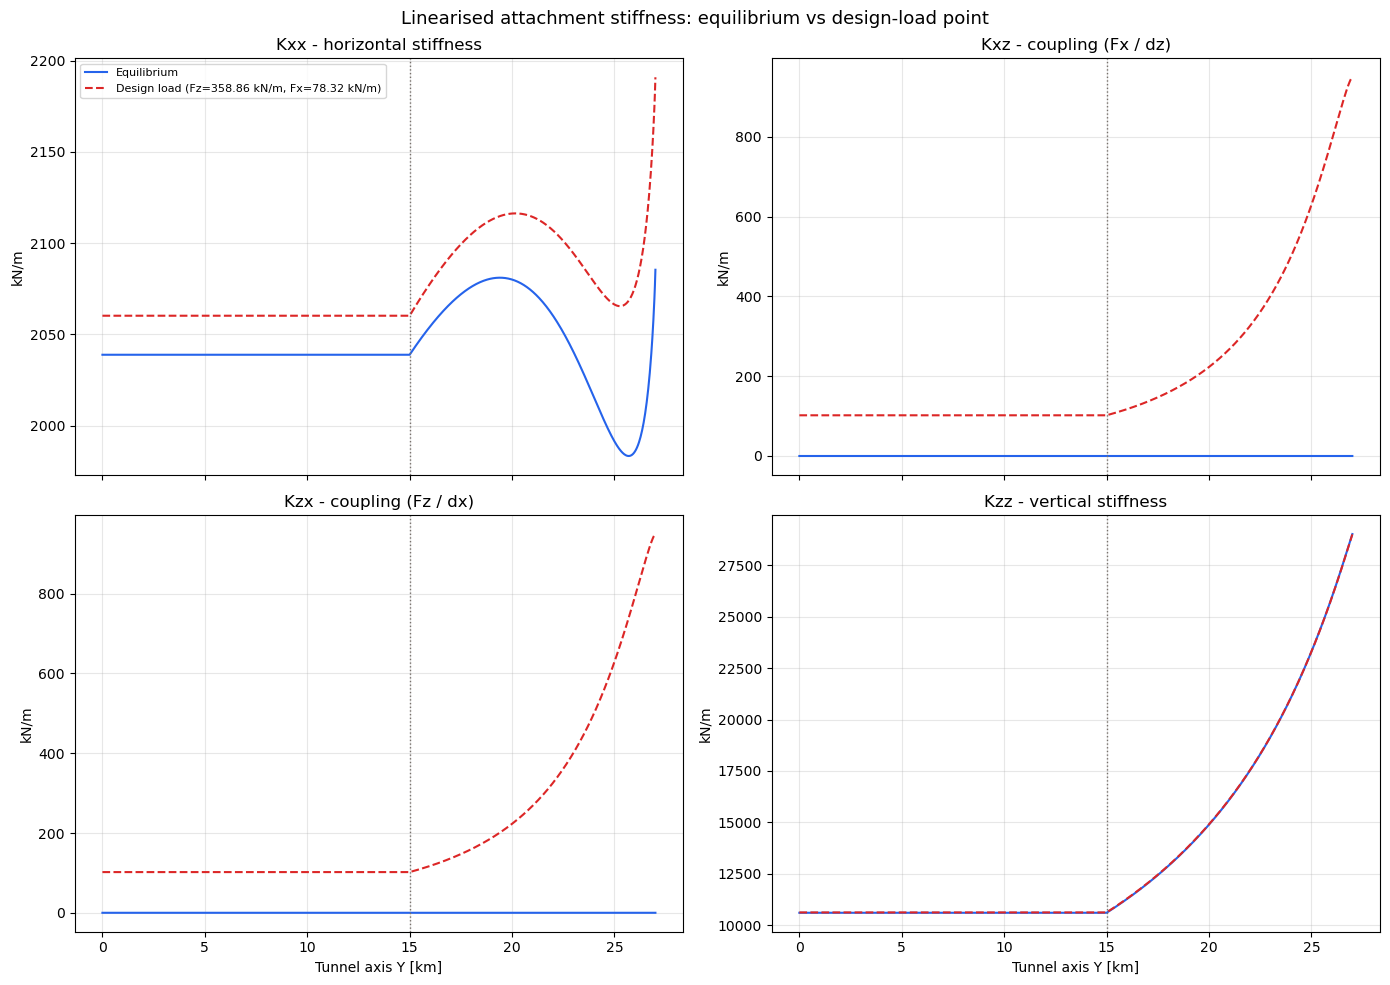

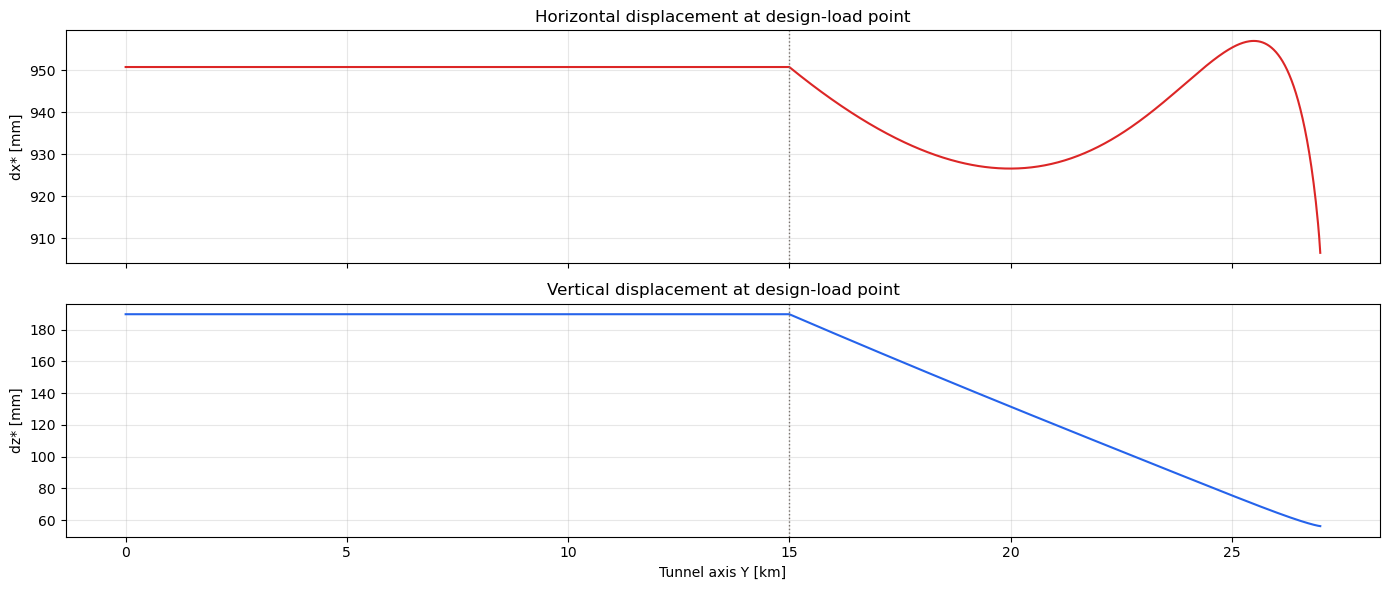

In [869]:
# ── Cell 8: Analytical 2x2 stiffness matrix per attachment ───────────────
#
# Evaluated at TWO reference states for each attachment row:
#   A) Equilibrium (neutral) position  - dx=0, dz=0
#   B) Design-load position            - (dx*, dz*) that balances
#        Fz = q_high * spacing  [kN upward buoyancy per row]
#        Fx = F_horiz * spacing [kN horizontal per row]
#
# Standard taut-cable stiffness tensor (per cable):
#   K = (EA/L0) * n*n^T  +  (T/L) * (I - n*n^T)
# where n and L are evaluated at the reference position.

q_high   = 358.86   # kN/m  vertical design load
F_horiz  = 78.32    # kN/m  horizontal design load
Fz_des_r = q_high  * spacing   # kN per row
Fx_des_r = F_horiz * spacing   # kN per row

def analytical_stiffness(a, dx0=0.0, dz0=0.0):
    K_att = np.zeros((2, 2))
    for sign in (-1, +1):
        x_fl = sign * x_att + dx0
        z_fl = a['z_fl'] + dz0
        ddx  = x_fl - sign * a['x_anch']
        ddz  = z_fl - a['z_anc']
        L    = np.sqrt(ddx**2 + ddz**2)
        n    = np.array([ddx / L, ddz / L])
        strain = (L - a['L0']) / a['L0']
        T      = max(0.0, EA * strain)
        K_elastic = (EA / a['L0']) * np.outer(n, n)
        K_geom    = (T  / L      ) * (np.eye(2) - np.outer(n, n))
        K_att    += K_elastic + K_geom
    return K_att / 1e3   # kN/m

# ── (A) Equilibrium linearisation ────────────────────────────────────────
K_matrices_eq = []
for a in attachments:
    K = analytical_stiffness(a, dx0=0.0, dz0=0.0)
    K_matrices_eq.append({
        'y': a['y'], 'd': a['d'],
        'Kxx': K[0,0], 'Kxz': K[0,1], 'Kzx': K[1,0], 'Kzz': K[1,1],
    })
df_K_eq = pd.DataFrame(K_matrices_eq)

# ── (B) Design-load linearisation ────────────────────────────────────────
K_matrices_des = []
for a in attachments:
    dx_star, dz_star = find_design_point(a, Fx_des_r, Fz_des_r)
    K = analytical_stiffness(a, dx0=dx_star, dz0=dz_star)
    K_matrices_des.append({
        'y': a['y'], 'd': a['d'],
        'dx_star': dx_star, 'dz_star': dz_star,
        'Kxx': K[0,0], 'Kxz': K[0,1], 'Kzx': K[1,0], 'Kzz': K[1,1],
    })
df_K_des = pd.DataFrame(K_matrices_des)

# Keep df_K pointing at equilibrium for backward compatibility
df_K = df_K_eq.copy()

# ── Print representative matrices ─────────────────────────────────────────
print('Per-attachment linearised stiffness [kN/m]')
print(f"  {'Depth':>6}  {'State':<22}  {'Kxx':>9}  {'Kxz':>9}  {'Kzx':>9}  {'Kzz':>9}")
print('-' * 75)
for d_t in [80, 70, 60, 50]:
    idx_eq  = (df_K_eq ['d'] - d_t).abs().idxmin()
    idx_des = (df_K_des['d'] - d_t).abs().idxmin()
    for lbl, df in [('Equilibrium (0,0)', df_K_eq), ('Design load', df_K_des)]:
        r = df.iloc[idx_eq if lbl.startswith('Eq') else idx_des]
        print(f"  d={d_t:2.0f} m  {lbl:<22}  "
              f"{r['Kxx']:9.2f}  {r['Kxz']:9.2f}  {r['Kzx']:9.2f}  {r['Kzz']:9.2f}")
    print()

# ── Plot both along tunnel axis ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
labels = [('Kxx', 'Kxx - horizontal stiffness'),
          ('Kxz', 'Kxz - coupling (Fx / dz)'),
          ('Kzx', 'Kzx - coupling (Fz / dx)'),
          ('Kzz', 'Kzz - vertical stiffness')]

for ax, (col, title) in zip(axes.flat, labels):
    ax.plot(df_K_eq ['y']/1000, df_K_eq [col], color='#2563EB', lw=1.5, label='Equilibrium')
    ax.plot(df_K_des['y']/1000, df_K_des[col], color='#DC2626', lw=1.5, ls='--',
            label=f'Design load (Fz={q_high} kN/m, Fx={F_horiz} kN/m)')
    ax.axvline(15, color='#78716C', ls=':', lw=1.0)
    ax.set_title(title); ax.set_ylabel('kN/m'); ax.grid(True, alpha=0.3)

axes.flat[0].legend(fontsize=8)
for ax in axes[1]: ax.set_xlabel('Tunnel axis Y [km]')
fig.suptitle('Linearised attachment stiffness: equilibrium vs design-load point', fontsize=13)
plt.tight_layout(); plt.show()

# ── Displaced position along tunnel axis ─────────────────────────────────
fig2, (ax_dx, ax_dz) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax_dx.plot(df_K_des['y']/1000, df_K_des['dx_star']*1e3, color='#DC2626', lw=1.5)
ax_dx.set(ylabel='dx* [mm]', title='Horizontal displacement at design-load point')
ax_dx.grid(True, alpha=0.3)
ax_dz.plot(df_K_des['y']/1000, df_K_des['dz_star']*1e3, color='#2563EB', lw=1.5)
ax_dz.set(ylabel='dz* [mm]', xlabel='Tunnel axis Y [km]',
          title='Vertical displacement at design-load point')
ax_dz.grid(True, alpha=0.3)
for ax in (ax_dx, ax_dz):
    ax.axvline(15, color='#78716C', ls=':', lw=1.0)
plt.tight_layout(); plt.show()


MOORING DESIGN CHECK SUMMARY

DESIGN CRITERIA
--------------------------------------------------
DC1  Pre-tension < 15% MBS (3973 kN)
     Worst pre-tension: 3755.8 kN (14.18% MBS) at y=0 m, d=80.0 m
     Result: PASS

DC2  Horizontal excursion < 10% water depth
     LC3: worst |dx| = 987.3 mm, limit = 5325 mm (d=53.2 m)  →  PASS
     LC4: worst |dx| = 956.9 mm, limit = 5375 mm (d=53.8 m)  →  PASS

LOAD CASE RESULTS (worst values along tunnel axis)

LC1  [LC1 – Peak vertical (no slack check)]
  Applied: buoyancy = 276.36 kN/m,  horizontal = 0.00 kN/m
  Peak tension   :   3755.8 kN (14.18% MBS)  at y=0 m, d=80.0 m
  Min  tension   :   3559.6 kN (13.44% MBS)  at y=26925 m, d=50.2 m
  Slack lines    : 0 rows (T_min <= 0)

LC2  [LC2 – Min vertical]
  Applied: buoyancy = 358.86 kN/m,  horizontal = 0.00 kN/m
  Peak tension   :   4874.2 kN (18.40% MBS)  at y=0 m, d=80.0 m
  Min  tension   :   4621.3 kN (17.45% MBS)  at y=26925 m, d=50.2 m
  Peak |dz|      : 194.3 mm  at y=0 m, d=80.0 m

LC3  

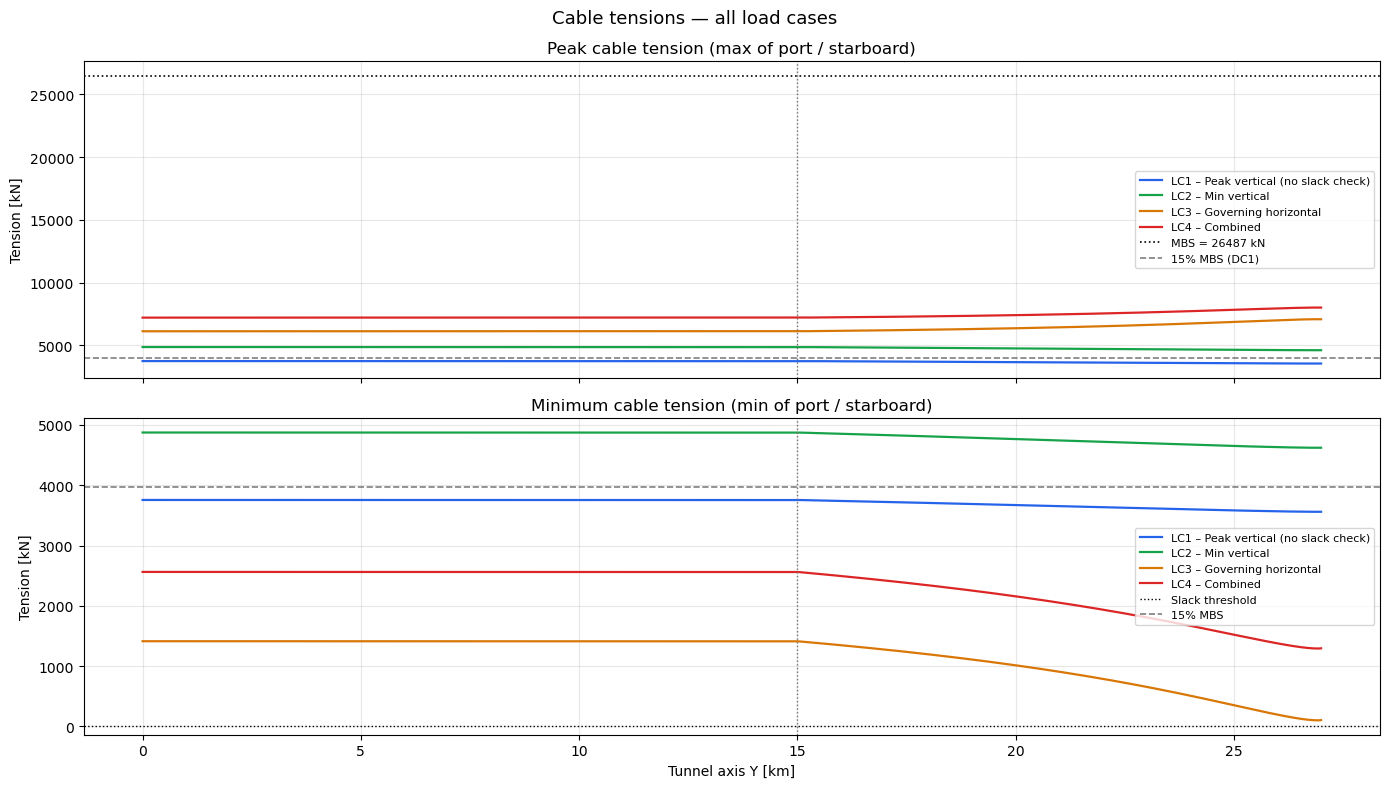

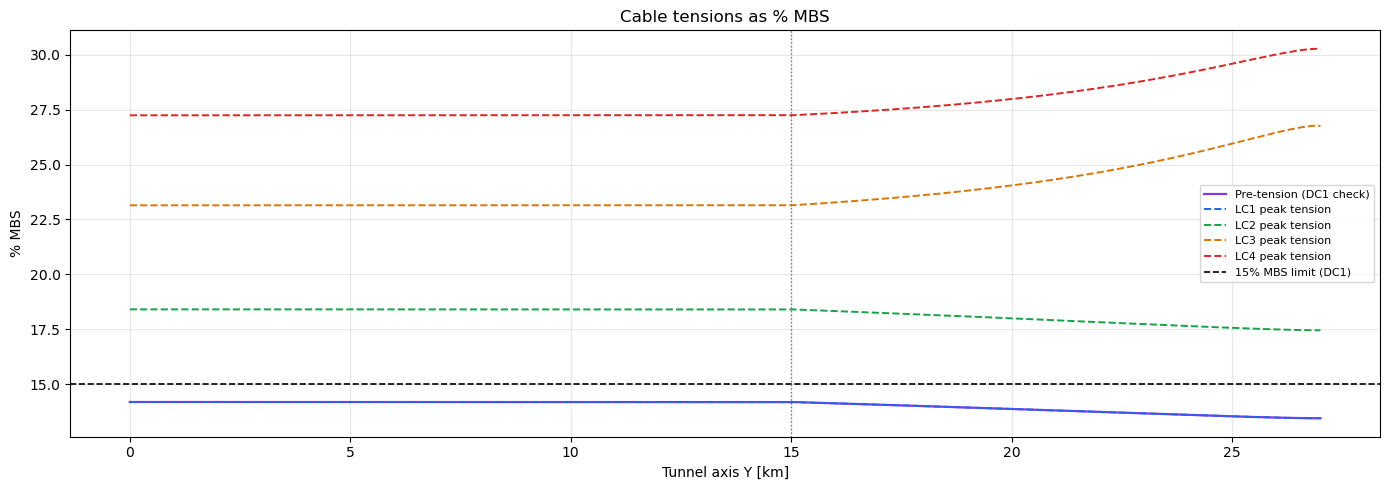

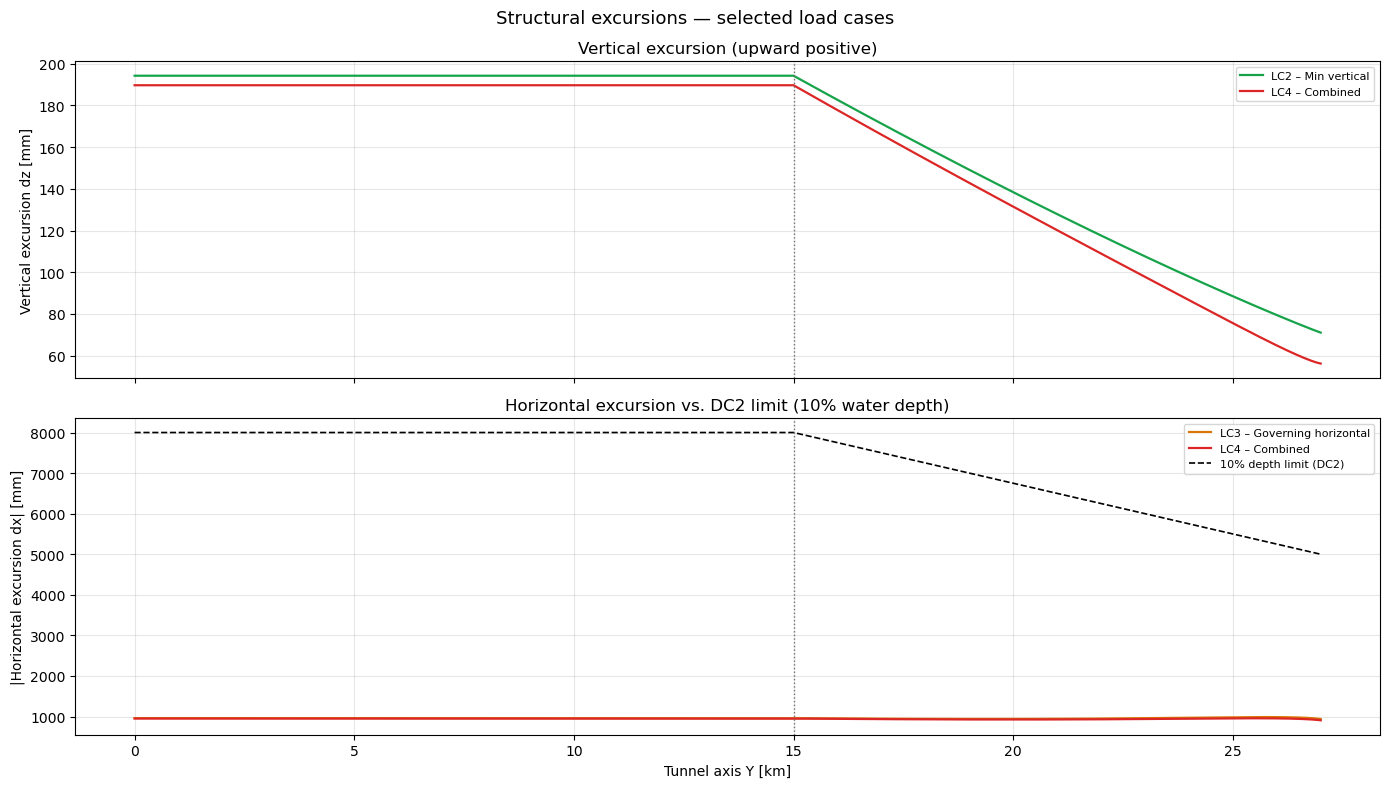

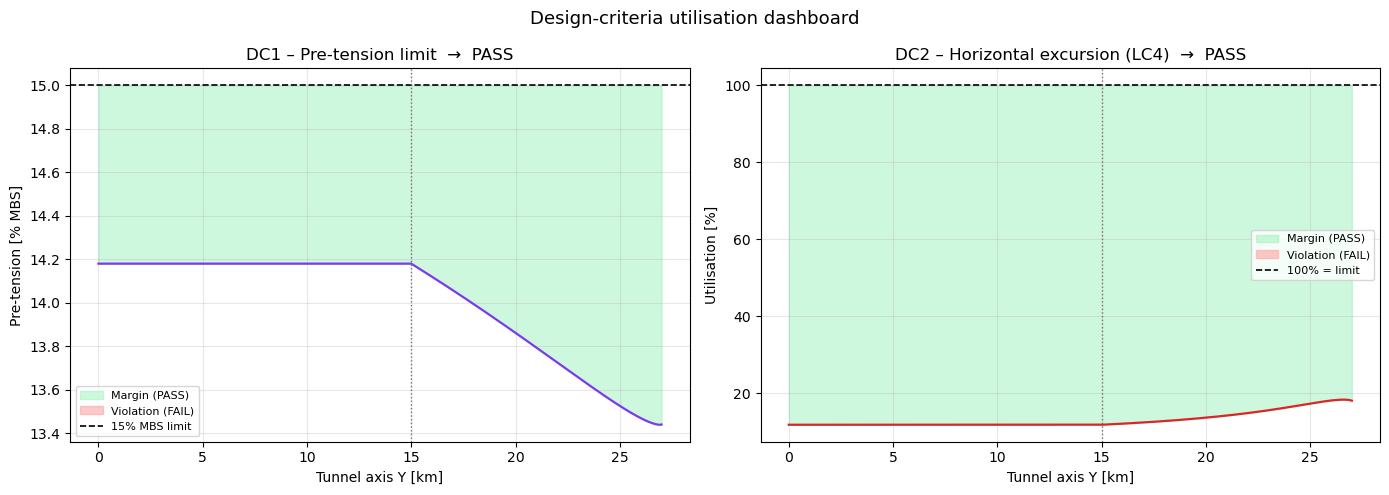

In [870]:
# ── Load-case checks & design-criteria verification ──────────────────────
#
# Load casesa
#   LC1  Peak vertical load   – buoyancy q_low  = 276.36 kN/m, Fx = 0
#          Check: minimum cable tension (lines must not go slack)
#   LC2  Min vertical load    – buoyancy q_high = 358.86 kN/m, Fx = 0
#          Check: vertical excursion; cable tension as % MBS
#   LC3  Governing horizontal – buoyancy q_low  = 276.36 kN/m, Fx = 78.32 kN/m
#          Check: peak & minimum line tension; horizontal excursion
#   LC4  Combined             – buoyancy q_high = 358.86 kN/m, Fx = 78.32 kN/m
#          Check: all of the above combined
#
# Design criteria
#   DC1  Pre-tension < 15 % MBS
#   DC2  Horizontal excursion < 10 % water depth
#
# All checks are evaluated for every attachment row along the tunnel axis.

# ── Parameters ────────────────────────────────────────────────────────────
MBS      = 26_487.0   # kN  – Minimal Breaking Strength (polyester 300 mm)
DC1_frac = 0.15       # pre-tension limit as fraction of MBS
DC2_frac = 0.10       # horizontal excursion limit as fraction of water depth

q_low    = 276.36     # kN/m  buoyancy, fully loaded
q_high   = 358.86     # kN/m  buoyancy, unloaded
F_horiz  =  78.32     # kN/m  governing horizontal load

# ── Helper functions ───────────────────────────────────────────────────────
def cable_state(a, dx, dz, side):
    sign = -1 if side == 'port' else +1
    x_fl = sign * x_att + dx
    z_fl = a['z_fl'] + dz
    ddx  = x_fl - sign * a['x_anch']
    ddz  = z_fl - a['z_anc']
    L    = np.sqrt(ddx**2 + ddz**2)
    T    = max(0.0, EA * (L - a['L0']) / a['L0'])
    return T / 1e3, ddx / L, ddz / L   # [kN], nx, nz

def pair_force(a, dx, dz):
    Fx = Fz = 0.0
    for s in ('port', 'starboard'):
        T, nx, nz = cable_state(a, dx, dz, s)
        Fx += -T * nx
        Fz += -T * nz
    return Fx, Fz   # [kN]

def find_equilibrium(a, Fx_kN, Fz_kN, x0=(0.02, 0.10)):
    def res(p):
        Fx, Fz = pair_force(a, p[0], p[1])
        return [Fx + Fx_kN, Fz + Fz_kN]
    sol, _, ier, _ = fsolve(res, x0, full_output=True)
    return sol, (ier == 1)

# ── Evaluate all four load cases for every attachment row ─────────────────
load_cases = {
    'LC1': dict(q=q_low,  Fh=0.0,     label='LC1 – Peak vertical (no slack check)'),
    'LC2': dict(q=q_high, Fh=0.0,     label='LC2 – Min vertical'),
    'LC3': dict(q=q_low,  Fh=F_horiz, label='LC3 – Governing horizontal'),
    'LC4': dict(q=q_high, Fh=F_horiz, label='LC4 – Combined'),
}

results = {lc: [] for lc in load_cases}

for a in attachments:
    for lc, lp in load_cases.items():
        Fz_row = lp['q'] * spacing   # kN per attachment row (upward buoyancy)
        Fx_row = lp['Fh'] * spacing  # kN per attachment row (horizontal)

        (dx, dz), ok = find_equilibrium(a, Fx_row, Fz_row)

        Tp, _, _ = cable_state(a, dx, dz, 'port')
        Ts, _, _ = cable_state(a, dx, dz, 'starboard')
        T_max = max(Tp, Ts)
        T_min = min(Tp, Ts)

        results[lc].append({
            'y'      : a['y'],
            'd'      : a['d'],
            'dx_mm'  : dx * 1e3,   # mm
            'dz_mm'  : dz * 1e3,   # mm
            'T_port' : Tp,
            'T_star' : Ts,
            'T_max'  : T_max,
            'T_min'  : T_min,
            'T_max_pct_MBS': 100 * T_max / MBS,
            'T_min_pct_MBS': 100 * T_min / MBS,
            'converged': ok,
        })

dfs = {lc: pd.DataFrame(v) for lc, v in results.items()}

# ── Design Criteria checks ─────────────────────────────────────────────────
# DC1 – Pre-tension < 15 % MBS  (evaluated at equilibrium, no applied load)
T0_all = []
for a in attachments:
    Tp, _, _ = cable_state(a, 0, 0, 'port')
    Ts, _, _ = cable_state(a, 0, 0, 'starboard')
    T0_all.append({'y': a['y'], 'd': a['d'],
                   'T0_kN': Tp, 'T0_pct_MBS': 100 * Tp / MBS})
df_T0 = pd.DataFrame(T0_all)

dc1_pass = (df_T0['T0_pct_MBS'] <= DC1_frac * 100).all()
dc1_worst_idx = df_T0['T0_pct_MBS'].idxmax()
dc1_worst = df_T0.loc[dc1_worst_idx]

# DC2 – Horizontal excursion < 10 % d  (worst across LC3 & LC4)
for lc in ('LC3', 'LC4'):
    dfs[lc]['dx_limit_mm'] = dfs[lc]['d'] * DC2_frac * 1e3   # mm
    dfs[lc]['dc2_ok']      = dfs[lc]['dx_mm'].abs() <= dfs[lc]['dx_limit_mm']

dc2_lc3_pass = dfs['LC3']['dc2_ok'].all()
dc2_lc4_pass = dfs['LC4']['dc2_ok'].all()

# ── Printed summary ────────────────────────────────────────────────────────
sep = '=' * 70
print(sep)
print('MOORING DESIGN CHECK SUMMARY')
print(sep)

print('\nDESIGN CRITERIA')
print('-' * 50)
print(f'DC1  Pre-tension < {DC1_frac*100:.0f}% MBS ({DC1_frac*MBS:.0f} kN)')
print(f'     Worst pre-tension: {dc1_worst.T0_kN:.1f} kN '
      f'({dc1_worst.T0_pct_MBS:.2f}% MBS) at y={dc1_worst.y:.0f} m, d={dc1_worst.d:.1f} m')
print(f'     Result: {"PASS" if dc1_pass else "FAIL"}')

print(f'\nDC2  Horizontal excursion < {DC2_frac*100:.0f}% water depth')
for lc in ('LC3', 'LC4'):
    fail_rows = dfs[lc][~dfs[lc]['dc2_ok']]
    worst_idx = dfs[lc]['dx_mm'].abs().idxmax()
    wr = dfs[lc].loc[worst_idx]
    ok = dc2_lc3_pass if lc == 'LC3' else dc2_lc4_pass
    print(f'     {lc}: worst |dx| = {abs(wr.dx_mm):.1f} mm, limit = {wr.dx_limit_mm:.0f} mm '
          f'(d={wr.d:.1f} m)  →  {"PASS" if ok else f"FAIL ({len(fail_rows)} rows exceed limit)"}')

print('\n' + sep)
print('LOAD CASE RESULTS (worst values along tunnel axis)')
print(sep)

for lc, lp in load_cases.items():
    df = dfs[lc]
    print(f'\n{lc}  [{lp["label"]}]')
    print(f'  Applied: buoyancy = {lp["q"]:.2f} kN/m,  '
          f'horizontal = {lp["Fh"]:.2f} kN/m')

    i_tmax = df['T_max'].idxmax()
    i_tmin = df['T_min'].idxmin()
    i_dx   = df['dx_mm'].abs().idxmax()
    i_dz   = df['dz_mm'].abs().idxmax()

    print(f'  Peak tension   : {df.loc[i_tmax, "T_max"]:8.1f} kN '
          f'({df.loc[i_tmax, "T_max_pct_MBS"]:.2f}% MBS)  at y={df.loc[i_tmax,"y"]:.0f} m, d={df.loc[i_tmax,"d"]:.1f} m')
    print(f'  Min  tension   : {df.loc[i_tmin, "T_min"]:8.1f} kN '
          f'({df.loc[i_tmin, "T_min_pct_MBS"]:.2f}% MBS)  at y={df.loc[i_tmin,"y"]:.0f} m, d={df.loc[i_tmin,"d"]:.1f} m')

    if lc == 'LC1':
        slack_rows = df[df['T_min'] <= 0]
        print(f'  Slack lines    : {len(slack_rows)} rows (T_min <= 0)')
    if lc in ('LC2', 'LC4'):
        print(f'  Peak |dz|      : {df.loc[i_dz, "dz_mm"]:.1f} mm  at y={df.loc[i_dz,"y"]:.0f} m, d={df.loc[i_dz,"d"]:.1f} m')
    if lc in ('LC3', 'LC4'):
        print(f'  Peak |dx|      : {df.loc[i_dx, "dx_mm"]:.1f} mm  at y={df.loc[i_dx,"y"]:.0f} m, d={df.loc[i_dx,"d"]:.1f} m')

print('\n' + sep)

# ── Figures ────────────────────────────────────────────────────────────────
COLOR = {'LC1': '#2563EB', 'LC2': '#16A34A', 'LC3': '#D97706', 'LC4': '#DC2626'}

# ── Figure 1: Tension along tunnel axis, all LCs ─────────────────────────
fig, (ax_max, ax_min) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for lc, df in dfs.items():
    ax_max.plot(df['y']/1000, df['T_max'], color=COLOR[lc], lw=1.6,
                label=load_cases[lc]['label'])
    ax_min.plot(df['y']/1000, df['T_min'], color=COLOR[lc], lw=1.6,
                label=load_cases[lc]['label'])

ax_max.axhline(MBS,           color='k',   lw=1.2, ls=':',  label=f'MBS = {MBS:.0f} kN')
ax_max.axhline(0.15*MBS,      color='grey',lw=1.2, ls='--', label='15% MBS (DC1)')
ax_min.axhline(0,             color='k',   lw=1.0, ls=':',  label='Slack threshold')
ax_min.axhline(0.15*MBS,      color='grey',lw=1.2, ls='--', label='15% MBS')

for ax in (ax_max, ax_min):
    ax.axvline(15, color='#78716C', ls=':', lw=1.0)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    ax.set_ylabel('Tension [kN]')

ax_max.set_title('Peak cable tension (max of port / starboard)')
ax_min.set_title('Minimum cable tension (min of port / starboard)')
ax_min.set_xlabel('Tunnel axis Y [km]')
fig.suptitle('Cable tensions — all load cases', fontsize=13)
plt.tight_layout(); plt.show()

# ── Figure 2: Tension as % MBS ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_T0['y']/1000, df_T0['T0_pct_MBS'], color='#7C3AED', lw=1.6, label='Pre-tension (DC1 check)')
for lc, df in dfs.items():
    ax.plot(df['y']/1000, df['T_max_pct_MBS'], color=COLOR[lc], lw=1.4,
            ls='--', label=f'{lc} peak tension')
ax.axhline(DC1_frac*100, color='k', lw=1.2, ls='--', label=f'{DC1_frac*100:.0f}% MBS limit (DC1)')
ax.set(xlabel='Tunnel axis Y [km]', ylabel='% MBS', title='Cable tensions as % MBS')
ax.axvline(15, color='#78716C', ls=':', lw=1.0)
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Figure 3: Excursions ───────────────────────────────────────────────────
fig, (ax_dz, ax_dx) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for lc in ('LC2', 'LC4'):
    ax_dz.plot(dfs[lc]['y']/1000, dfs[lc]['dz_mm'], color=COLOR[lc], lw=1.6,
               label=load_cases[lc]['label'])

for lc in ('LC3', 'LC4'):
    df = dfs[lc]
    ax_dx.plot(df['y']/1000, df['dx_mm'].abs(), color=COLOR[lc], lw=1.6,
               label=load_cases[lc]['label'])

ax_dx.plot(dfs['LC4']['y']/1000, dfs['LC4']['dx_limit_mm'], color='k',
           lw=1.2, ls='--', label=f'10% depth limit (DC2)')

for ax in (ax_dz, ax_dx):
    ax.axvline(15, color='#78716C', ls=':', lw=1.0)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax_dz.set(ylabel='Vertical excursion dz [mm]',
          title='Vertical excursion (upward positive)')
ax_dx.set(ylabel='|Horizontal excursion dx| [mm]',
          xlabel='Tunnel axis Y [km]',
          title='Horizontal excursion vs. DC2 limit (10% water depth)')
fig.suptitle('Structural excursions — selected load cases', fontsize=13)
plt.tight_layout(); plt.show()

# ── Figure 4: Design-criteria dashboard ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DC1 margin
margin_dc1 = DC1_frac*100 - df_T0['T0_pct_MBS']
axes[0].plot(df_T0['y']/1000, df_T0['T0_pct_MBS'], color='#7C3AED', lw=1.6)
axes[0].fill_between(df_T0['y']/1000, df_T0['T0_pct_MBS'], DC1_frac*100,
                     where=(df_T0['T0_pct_MBS'] <= DC1_frac*100),
                     color='#86EFAC', alpha=0.4, label='Margin (PASS)')
axes[0].fill_between(df_T0['y']/1000, df_T0['T0_pct_MBS'], DC1_frac*100,
                     where=(df_T0['T0_pct_MBS'] > DC1_frac*100),
                     color='#FCA5A5', alpha=0.6, label='Violation (FAIL)')
axes[0].axhline(DC1_frac*100, color='k', lw=1.2, ls='--', label=f'{DC1_frac*100:.0f}% MBS limit')
axes[0].axvline(15, color='#78716C', ls=':', lw=1.0)
axes[0].set(xlabel='Tunnel axis Y [km]', ylabel='Pre-tension [% MBS]',
            title=f'DC1 – Pre-tension limit  →  {"PASS" if dc1_pass else "FAIL"}')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

# DC2 utilisation (LC4 worst case)
util = dfs['LC4']['dx_mm'].abs() / dfs['LC4']['dx_limit_mm'] * 100
axes[1].plot(dfs['LC4']['y']/1000, util, color='#DC2626', lw=1.6)
axes[1].fill_between(dfs['LC4']['y']/1000, util, 100,
                     where=(util <= 100), color='#86EFAC', alpha=0.4, label='Margin (PASS)')
axes[1].fill_between(dfs['LC4']['y']/1000, util, 100,
                     where=(util > 100), color='#FCA5A5', alpha=0.6, label='Violation (FAIL)')
axes[1].axhline(100, color='k', lw=1.2, ls='--', label='100% = limit')
axes[1].axvline(15, color='#78716C', ls=':', lw=1.0)
axes[1].set(xlabel='Tunnel axis Y [km]', ylabel='Utilisation [%]',
            title=f'DC2 – Horizontal excursion (LC4)  →  {"PASS" if dc2_lc4_pass else "FAIL"}')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle('Design-criteria utilisation dashboard', fontsize=13)
plt.tight_layout(); plt.show()


In [871]:
# # ── Cell 7: Force-excursion and stiffness diagrams at discrete depths ────
# # Single attachment pair (port + starboard) response across a range of
# # horizontal (dx) and vertical (dz) displacements, evaluated at 7 depths.

# depths_plot = [80, 75, 70, 65, 60, 55, 50]
# dx_range    = np.linspace(-4.0,  4.0, 300)   # m
# dz_range    = np.linspace(-1.0,  3.0, 300)   # m (positive = upward)

# def attachment_forces(a, dx, dz):
#     """
#     Net restoring force [N] on structure for one attachment pair (port+starboard).
#     Returns (Fx, Fz).  Sign: positive = rightward / upward force on structure.
#     """
#     Fx = 0.0; Fz = 0.0
#     for sign in (-1, +1):   # port=-1, starboard=+1
#         x_fl_d = sign * x_att + dx
#         z_fl_d = a['z_fl'] + dz
#         ddx    = x_fl_d - sign * a['x_anch']
#         ddz    = z_fl_d - a['z_anc']
#         L      = np.sqrt(ddx**2 + ddz**2)
#         strain = (L - a['L0']) / a['L0']
#         T      = max(0.0, EA * strain)
#         Fx    += -T * ddx / L   # restoring (toward anchor)
#         Fz    += -T * ddz / L
#     return Fx, Fz

# # Lookup: target depth → representative attachment
# depth_att = {}
# for d_t in depths_plot:
#     idx = (df_att['d'] - d_t).abs().idxmin()
#     depth_att[d_t] = attachments[idx]

# # cmap   = plt.get_cmap('plasma', len(depths_plot))
# colors = plt.cm.viridis(np.linspace(0, 1, len(depths_plot)))
# # colors = [cmap(i) for i in range(len(depths_plot))]

# # ── Force-excursion ───────────────────────────────────────────────────────
# fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# (ax_Fx_dx, ax_Fz_dx), (ax_Fx_dz, ax_Fz_dz) = axes

# for col, d_t in zip(colors, depths_plot):
#     a   = depth_att[d_t]; lbl = f'd = {d_t} m'
#     Fx_dx = [attachment_forces(a, dx, 0)[0]/1e3 for dx in dx_range]
#     Fz_dx = [attachment_forces(a, dx, 0)[1]/1e3 for dx in dx_range]
#     Fx_dz = [attachment_forces(a, 0,  dz)[0]/1e3 for dz in dz_range]
#     Fz_dz = [attachment_forces(a, 0,  dz)[1]/1e3 for dz in dz_range]
#     ax_Fx_dx.plot(dx_range, Fx_dx, color=col, lw=1.8, label=lbl)
#     ax_Fz_dx.plot(dx_range, Fz_dx, color=col, lw=1.8, label=lbl)
#     ax_Fx_dz.plot(dz_range, Fx_dz, color=col, lw=1.8, label=lbl)
#     ax_Fz_dz.plot(dz_range, Fz_dz, color=col, lw=1.8, label=lbl)

# for ax in axes.flat:
#     # ax.axhline(0, color='k', lw=0.7, ls='--')
#     # ax.axvline(0, color='k', lw=0.7, ls='--')
#     ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ax_Fx_dx.set(title='Fx vs. horizontal excursion', xlabel='dx [m]', ylabel='Fx [kN]')
# ax_Fz_dx.set(title='Fz vs. horizontal excursion', xlabel='dx [m]', ylabel='Fz [kN]')
# ax_Fx_dz.set(title='Fx vs. vertical excursion',   xlabel='dz [m]', ylabel='Fx [kN]')
# ax_Fz_dz.set(title='Fz vs. vertical excursion',   xlabel='dz [m]', ylabel='Fz [kN]')

# fig.suptitle('Force-excursion — single attachment pair', fontsize=13)
# plt.tight_layout(); plt.show()

# # ── Stiffness (numerical derivative) ─────────────────────────────────────
# fig2, axes2 = plt.subplots(2, 2, figsize=(16, 11))
# (ax_Kxx_dx, ax_Kzx_dx), (ax_Kxz_dz, ax_Kzz_dz) = axes2

# eps = 1e-4   # m perturbation for central difference

# for col, d_t in zip(colors, depths_plot):
#     a   = depth_att[d_t]; lbl = f'd = {d_t} m'
#     Kxx = [-(attachment_forces(a,dx+eps,0)[0]-attachment_forces(a,dx-eps,0)[0])/(2*eps*1e3)
#            for dx in dx_range]
#     Kzx = [-(attachment_forces(a,dx+eps,0)[1]-attachment_forces(a,dx-eps,0)[1])/(2*eps*1e3)
#            for dx in dx_range]
#     Kxz = [-(attachment_forces(a,0,dz+eps)[0]-attachment_forces(a,0,dz-eps)[0])/(2*eps*1e3)
#            for dz in dz_range]
#     Kzz = [-(attachment_forces(a,0,dz+eps)[1]-attachment_forces(a,0,dz-eps)[1])/(2*eps*1e3)
#            for dz in dz_range]
#     ax_Kxx_dx.plot(dx_range, Kxx, color=col, lw=1.8, label=lbl)
#     ax_Kzx_dx.plot(dx_range, Kzx, color=col, lw=1.8, label=lbl)
#     ax_Kxz_dz.plot(dz_range, Kxz, color=col, lw=1.8, label=lbl)
#     ax_Kzz_dz.plot(dz_range, Kzz, color=col, lw=1.8, label=lbl)

# for ax in axes2.flat:
#     # ax.axhline(0, color='k', lw=0.7, ls='--')
#     # ax.axvline(0, color='k', lw=0.7, ls='--')
#     ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ax_Kxx_dx.set(title='Kxx (dFx/dx) vs. dx', xlabel='dx [m]', ylabel='kN/m')
# ax_Kzx_dx.set(title='Kzx (dFz/dx) vs. dx', xlabel='dx [m]', ylabel='kN/m')
# ax_Kxz_dz.set(title='Kxz (dFx/dz) vs. dz', xlabel='dz [m]', ylabel='kN/m')
# ax_Kzz_dz.set(title='Kzz (dFz/dz) vs. dz', xlabel='dz [m]', ylabel='kN/m')

# fig2.suptitle('Linearised stiffness vs. excursion — single attachment pair', fontsize=13)
# plt.tight_layout(); plt.show()


In [872]:
# # ── Cell 8: Analytical 2×2 stiffness matrix per attachment ───────────────
# #
# # Standard taut-cable stiffness tensor (per cable):
# #   K = (EA/L0) * n⊗n  +  (T/L) * (I - n⊗n)
# #         elastic             geometric (transverse)
# # where n = unit vector along cable (anchor → attachment).
# # Sum port + starboard to get the attachment pair stiffness [[Kxx,Kxz],[Kzx,Kzz]].

# K_matrices = []

# for a in attachments:
#     T0 = a['T0_kN'] * 1e3   # N
#     K_att = np.zeros((2, 2))

#     for sign in (-1, +1):   # port=-1, starboard=+1
#         ddx  = sign * x_att - sign * a['x_anch']   # = sign*(x_att - x_anch)
#         ddz  = a['z_fl'] - a['z_anc']              # positive upward
#         L    = np.sqrt(ddx**2 + ddz**2)             # = a['L_geom']
#         n    = np.array([ddx / L, ddz / L])         # unit vector [nx, nz]

#         K_elastic = (EA / a['L0']) * np.outer(n, n)
#         K_geom    = (T0 / L)      * (np.eye(2) - np.outer(n, n))
#         K_att    += K_elastic + K_geom              # restoring sign already correct

#     K_matrices.append({
#         'y':   a['y'],   'd':   a['d'],
#         'K':   K_att / 1e3,              # kN/m
#         'Kxx': K_att[0,0] / 1e3,
#         'Kxz': K_att[0,1] / 1e3,
#         'Kzx': K_att[1,0] / 1e3,
#         'Kzz': K_att[1,1] / 1e3,
#     })

# df_K = pd.DataFrame([{'y':k['y'],'d':k['d'],
#                        'Kxx':k['Kxx'],'Kxz':k['Kxz'],
#                        'Kzx':k['Kzx'],'Kzz':k['Kzz']} for k in K_matrices])

# print("Per-attachment linearised stiffness matrices K  [kN/m]")
# print("  K = [[Kxx, Kxz], [Kzx, Kzz]]\n")
# print(df_K.to_string(index=False, float_format='{:.2f}'.format))

# # ── Stiffness components along tunnel axis ────────────────────────────────
# fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True)
# labels = [('Kxx','Kxx — horizontal stiffness'),
#           ('Kxz','Kxz — coupling (Fx / dz)'),
#           ('Kzx','Kzx — coupling (Fz / dx)'),
#           ('Kzz','Kzz — vertical stiffness')]

# for ax, (col, title) in zip(axes.flat, labels):
#     ax.plot(df_K['y']/1000, df_K[col], color='#2563EB', lw=1.5)
#     ax.axvline(15, color='#78716C', ls='--', lw=1.0, label='Depth transition')
#     ax.set_title(title); ax.set_ylabel('kN/m'); ax.grid(True, alpha=0.3)

# axes.flat[0].legend()
# for ax in axes[1]: ax.set_xlabel('Tunnel axis Y [km]')
# fig.suptitle('Linearised attachment stiffness along tunnel axis', fontsize=13)
# plt.tight_layout(); plt.show()

# # ── Print representative matrices explicitly ──────────────────────────────
# print("\nRepresentative stiffness matrices:")
# for d_t in [80, 70, 60, 50]:
#     idx = (df_K['d'] - d_t).abs().idxmin()
#     k   = K_matrices[idx]
#     print(f"  y={k['y']:.0f} m,  d={k['d']:.0f} m:")
#     print(f"    K = [[{k['Kxx']:8.2f},  {k['Kxz']:8.2f}],")
#     print(f"         [{k['Kzx']:8.2f},  {k['Kzz']:8.2f}]]  kN/m")
